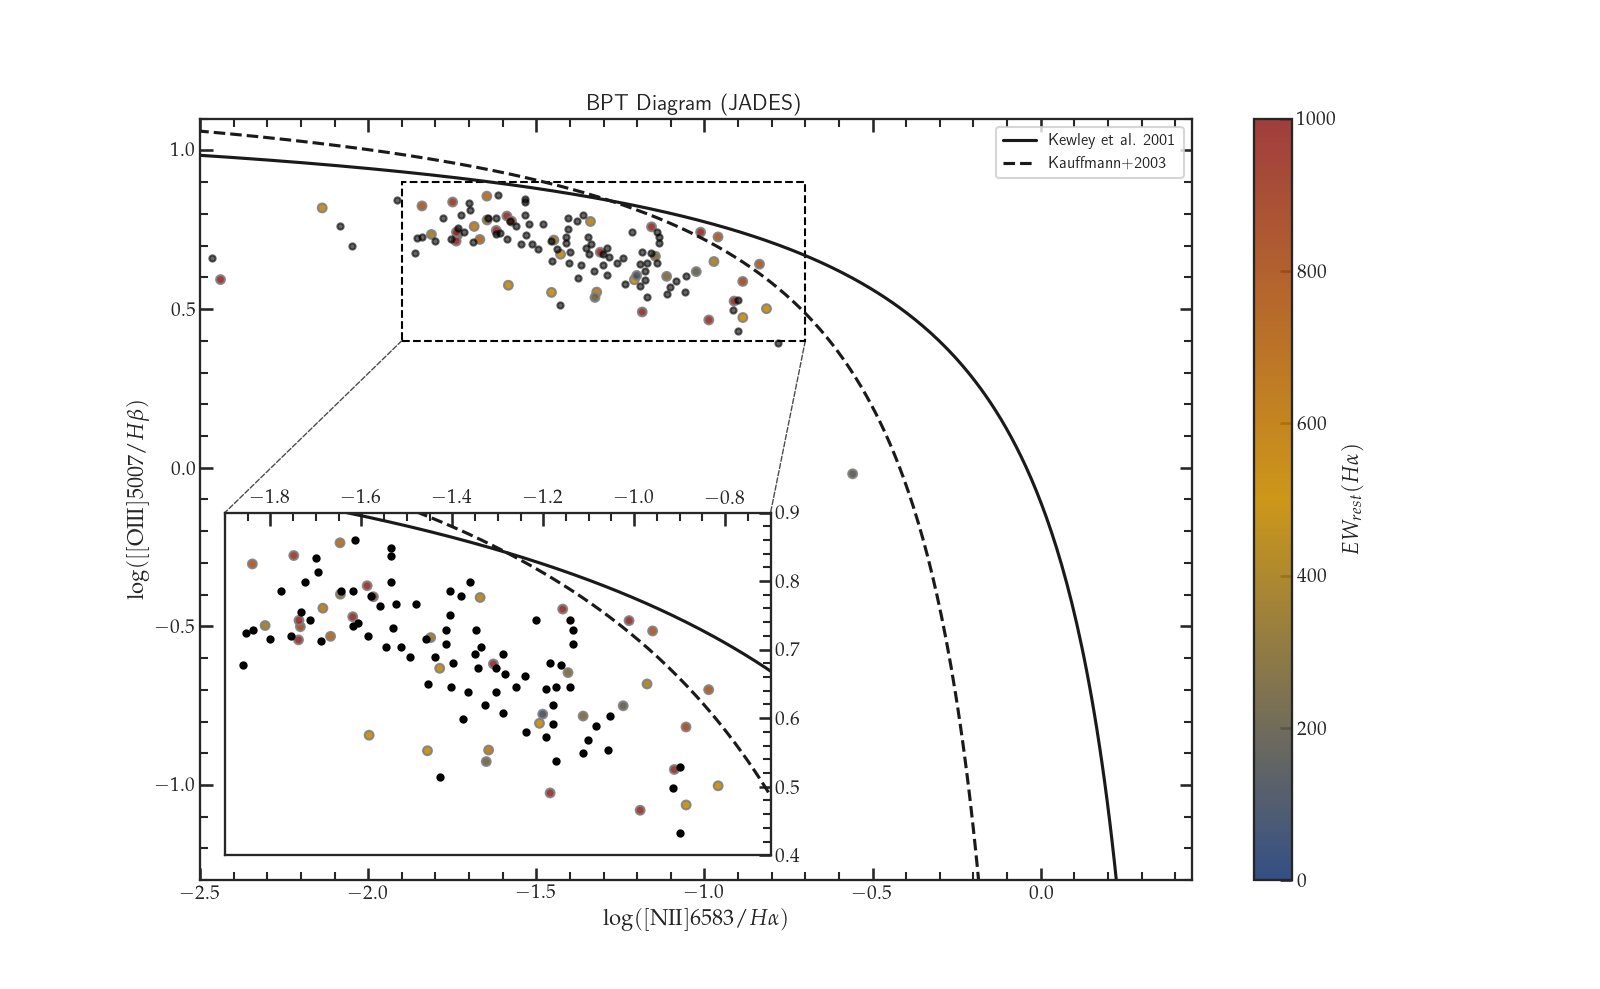

In [1]:
from matplotlib.patches import Rectangle
from matplotlib.patches import ConnectionPatch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

%matplotlib widget
#================= Plot Settings =================#
# Latex rendering
plt.rc('font', **{'family': 'serif', 'serif': ['palatino']}) #Helvetica
plt.rc('text', usetex=True)
plt.rc('font', weight='bold')

# --- Cosmology palette (normalized RGB) ---
COSMO_COLORS = {
    "deep_blue": (30/255, 60/255, 120/255),
    "warm_gold": (200/255, 140/255, 0/255),
    "dark_teal": (0/255, 130/255, 90/255),
    "soft_crimson": (150/255, 40/255, 40/255),
    "cool_gray": (120/255, 120/255, 120/255),
    }

sns.set_theme(
    style="ticks",
    context='talk',
    rc={
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "axes.grid": True,
    })

sns.set_palette([
    COSMO_COLORS["deep_blue"],
    "black",
    COSMO_COLORS["warm_gold"],
    COSMO_COLORS["cool_gray"],
    COSMO_COLORS["dark_teal"],
    COSMO_COLORS["soft_crimson"],
    ])

#General Settings
plt.rc('axes', titlesize=16)     # fontsize of the axes title
plt.rc('axes', labelsize=16)     # fontsize of the x and y labels
plt.rc('axes', linewidth=1.65 )   # width of the frame
plt.rc('xtick', labelsize=14)    # fontsize of the tick labels
plt.rc('ytick', labelsize=14)    # fontsize of the tick labels
plt.rc('legend', fontsize=12)    # legend fontsize
plt.rc('font', size=16)          # controls default text sizes



def compute_axes(source='MAST', filter='G235M', save=False, show=True):
    #================= File Reading =================#
    # Read the TSV file
    df_all = pd.read_csv('./Output_data/Line_fluxes_all_filters.tsv', sep='\t')
    equivalent_widths = pd.read_csv('./Equivalent_width_data.tsv', sep='\t')
    

    if source == 'MAST':
        suffix = f'MAST {filter}'
    elif source == 'JADES':
        suffix = f'JADES {filter}'


    # Create a sub dataframe with ID, redshift, and all columns containing the suffix
    cols = [col for col in df_all.columns if suffix in col]
    df_sub = df_all[['ID', 'redshift'] + cols].copy()
    
    #Define arrays for each axis on the BPT diagram
    blue_axis = np.log10(df_sub[f'Flux ([OIII]5007) {suffix}'] / df_sub[f'Flux (Hb 4861) {suffix}'])
    red_axis = np.log10(df_sub[f'Flux ([NII]6583) {suffix}'] / df_sub[f'Flux (Ha 6563) {suffix}'])
    
    result = {
        'ID': df_sub['ID'],
        'redshift': df_sub['redshift'],
        'blue_axis': blue_axis,
        'red_axis': red_axis,
        'NII': df_sub[f'Flux ([NII]6583) {suffix}'],
        'NII_err': df_sub[f'F_err([NII]6583) {suffix}'],
        'Hb': df_sub[f'Flux (Hb 4861) {suffix}'],
        'Hb_err': df_sub[f'F_err(Hb 4861) {suffix}'],
        'EW MAST': -1*equivalent_widths['EW(Ha) MAST'],
        'EW JADES': -1*equivalent_widths['EW(Ha) JADES']
    }
    
    return pd.DataFrame(result)



def get_bpt_dataframe(source):
    df_235 = compute_axes(source=source, filter='G235M')
    df_395 = compute_axes(source=source, filter='G395M')
    df_395H = compute_axes(source=source, filter='G395H')

    keys = ['ID', 'redshift', f'EW {source}']
    cols = ['blue_axis', 'red_axis', 'NII', 'NII_err', 'Hb', 'Hb_err']

    base = (
        df_235[keys].merge(df_395[keys], on=keys, how='inner')
        .merge(df_395H[keys], on=keys, how='inner')
    )

    a = base.merge(df_235[keys + cols], on=keys, how='left')
    b = base.merge(df_395[keys + cols], on=keys, how='left')
    c = base.merge(df_395H[keys + cols], on=keys, how='left')

    df_final = base.copy()
    for col in cols:
        df_final[col] = a[col].combine_first(b[col]).combine_first(c[col])

    df_final['red_err'] = df_final['NII'] < df_final['NII_err']
    df_final['blue_err'] = df_final['Hb'] < df_final['Hb_err']
    return df_final



# rectangle region matching the inset limits
x0, x1 = -1.9, -0.7
y0, y1 = 0.4, 0.9

fig, ax = plt.subplots(figsize=(16, 9.89))

x_kewly = np.linspace(-3.5, 0.25, 500)
x_kauff = np.linspace(-3.5, 0., 500)
y_kewly = 0.61 / (x_kewly - 0.47) + 1.19
y_kauff = 0.61 / (x_kauff - 0.05) + 1.3
ax.plot(x_kewly, y_kewly, color='k', label='Kewley et al. 2001')
ax.plot(x_kauff, y_kauff, color='k', linestyle='--', label='Kauffmann+2003')

ax.set_xlim(-2.5, 0.45)
ax.set_ylim(-1.3, 1.1)
ax.set_xlabel(r'$\log([\mathrm{NII}]6583/H \alpha)$')
ax.set_ylabel(r'$\log([\mathrm{[OIII}]5007/H\beta)$')
ax.minorticks_on()
ax.grid(False)
ax.legend()

gray_red_cmap = LinearSegmentedColormap.from_list(
    'gray_red',
    [COSMO_COLORS['deep_blue'], COSMO_COLORS['warm_gold'], COSMO_COLORS['soft_crimson']]
)

exclude_ids = {3334, 3968, 4197, 4282, 5329, 7624, 9452, 17072, 17260, 18028, 10001587, 10001892, 10005113, 10005447, 10009693, 10009848, 10013704, 10015338}
df_jades = get_bpt_dataframe('JADES')

df_jades_filtered = df_jades[~df_jades['ID'].isin(exclude_ids)].reset_index(drop=True)


scatter = ax.scatter(
    df_jades_filtered['red_axis'],
    df_jades_filtered['blue_axis'],
    s=40,
    c=df_jades_filtered['EW JADES'],
    cmap=gray_red_cmap,
    edgecolor='grey',
    alpha=0.9,
    vmin=0,
    vmax=1000
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label(r'$EW_{rest}(H\alpha)$')
ax.set_title('BPT Diagram (JADES)')

localsample = pd.read_csv('./Output_data/local_sample.tsv', sep='\t')
sampĺe_red = localsample['red_axis']
sample_blue = localsample['blue_axis']


local_scatter = ax.scatter(
    sampĺe_red,
    sample_blue,
    color='black',
    s=20,
    edgecolor='black',
    alpha=0.6
)


# add rectangle on the main plot
rect = Rectangle(
    (x0, y0),
    x1 - x0,
    y1 - y0,
    linewidth=1.5,
    edgecolor='black',
    linestyle='--',
    fill=False
)
ax.add_patch(rect)



# Create the main plot
axins = inset_axes(ax, width="55%", height="45%", loc='lower left', borderpad=1.5)
axins.plot(x_kewly, y_kewly, color='k')
axins.plot(x_kauff, y_kauff, color='k', linestyle='--')
axins.scatter(
    df_jades_filtered['red_axis'],
    df_jades_filtered['blue_axis'],
    s=40,
    c=df_jades_filtered['EW JADES'],
    cmap=gray_red_cmap,
    edgecolor='grey',
    alpha=0.9,
    vmin=0,
    vmax=1000
)
axins.scatter(
    sampĺe_red,
    sample_blue,
    color='black',
    s=20,
    edgecolor='black',
    alpha=1
)
axins.set_xlim(x0, x1)
axins.set_ylim(y0, y1)
axins.minorticks_on()
axins.grid(False)
axins.xaxis.tick_top()
axins.yaxis.tick_right()




"""
for x, y, obj_id in zip(df_jades_filtered['red_axis'], df_jades_filtered['blue_axis'], df_jades_filtered['ID']):
    ax.annotate(
        str(obj_id),
        (x, y),
        textcoords="offset points",
        xytext=(3, 3),
        ha="left",
        fontsize=8,
        color=COSMO_COLORS['deep_blue']
    )

for x, y, obj_id in zip(df_jades_filtered['red_axis'], df_jades_filtered['blue_axis'], df_jades_filtered['ID']):
    if x0 <= x <= x1 and y0 <= y <= y1:
        axins.annotate(
            str(obj_id),
            (x, y),
            textcoords="offset points",
            xytext=(3, 3),
            ha="left",
            fontsize=8,
            color=COSMO_COLORS['deep_blue']
        )
"""
connector1 = ConnectionPatch(
    xyA=(x0, y0),
    coordsA=ax.transData,
    xyB=(0, 1),
    coordsB=axins.transAxes,
    arrowstyle='-',
    linestyle='--',
    linewidth=1,
    color='black',
    alpha=0.7
)
connector2 = ConnectionPatch(
    xyA=(x1, y0),
    coordsA=ax.transData,
    xyB=(1, 1),
    coordsB=axins.transAxes,
    arrowstyle='-',
    linestyle='--',
    linewidth=1,
    color='black',
    alpha=0.7
)
ax.add_artist(connector1)
ax.add_artist(connector2)




plt.show()

In [2]:
len(df_jades_filtered.ID.unique())


45

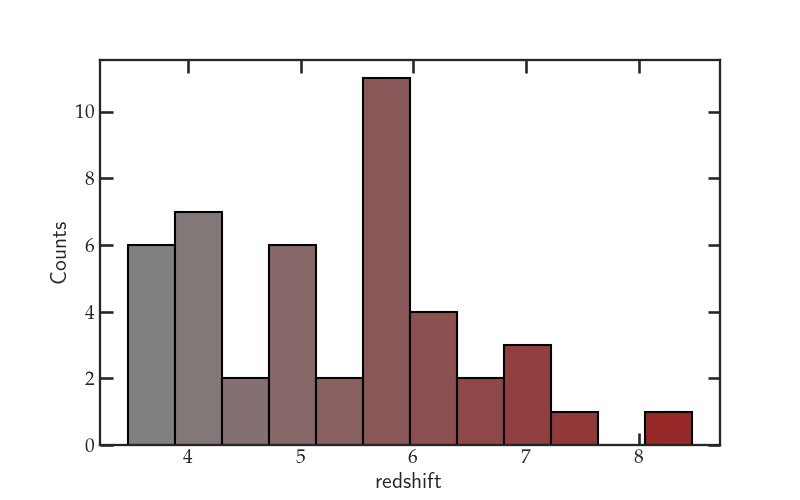

In [8]:
n_bins = 12
counts, bins = np.histogram(df_jades_filtered['redshift'].dropna(), bins=n_bins)
bin_centers = (bins[:-1] + bins[1:]) / 2

cmap = LinearSegmentedColormap.from_list('gray_to_red', ['gray', COSMO_COLORS['soft_crimson']])
colors = cmap(np.linspace(0, 1, n_bins))

plt.figure(figsize=(8, 5))
plt.bar(
    bin_centers,
    counts,
    width=np.diff(bins),
    color=colors,
    edgecolor='black',
    align='center'
)
plt.xlabel('redshift')
plt.ylabel('Counts')
plt.grid(False)

plt.show()

/home/nicolas/Documents/Research/PhD/JWST-Data/Medium_Resolution/Spectra1D/JADES/hlsp_jades_jwst_nirspec_goods-s-deephst-00008083_f290lp-g395m_v1.0_x1d.fits


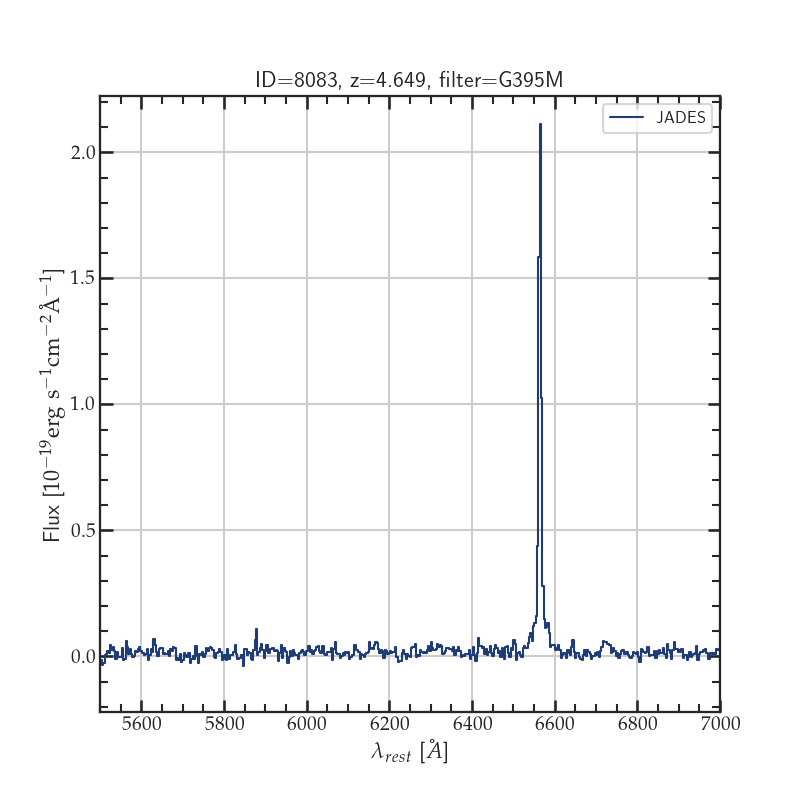

/home/nicolas/Documents/Research/PhD/JWST-Data/High_Resolution/Spectra1D/JADES/hlsp_jades_jwst_nirspec_goods-s-deephst-00008083_f290lp-g395h_v1.0_x1d.fits


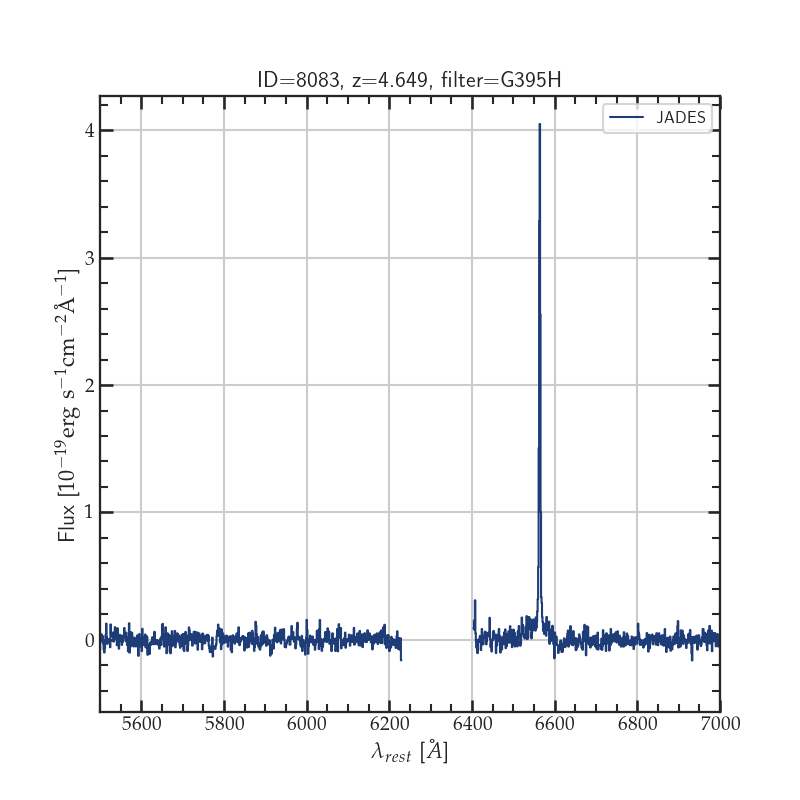

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from astropy.io import fits
from astropy import units as u
import matplotlib.pyplot as plt



#Define source path where the files are
path = Path('/home/nicolas/Documents/Research/PhD/JWST-Data/')
prism_folder = path / 'PRISM/Spectra1D'
medium_folder = path / 'Medium_Resolution/Spectra1D'
high_folder = path / 'High_Resolution/Spectra1D'
plots_folder = path / 'Objects'

#Extract data with Pandas
df = pd.read_csv("list_of_candidates.tsv", sep='\t')
ID_array = df["NIRSpec_ID"]
z_array = df["redshift"]


def main():

    
    ID = 8083
    
    for i in ID_array:
        
        index = np.where(ID_array == ID)[0][0]

    for filter in ['G395M', 'G395H']:
        #save_plots(index, filter=filter, frame='rest', which='both', context='paper')
        plot_spectrum_comparison(index, filter=filter, frame='rest', which='JADES', show=True)

    
#================================================================
#====================== Plotting functions ======================
#================================================================
def save_plots(index, filter='PRISM', frame='rest', which='both',context='talk'):

    #================= Plot Settings =================#
    # Latex rendering
    plt.rc('font', **{'family': 'serif', 'serif': ['palatino']}) #Helvetica
    plt.rc('text', usetex=True)
    plt.rc('font', weight='bold')

    # --- Cosmology palette (normalized RGB) ---
    COSMO_COLORS = {
        "deep_blue": (30/255, 60/255, 120/255),
        "warm_gold": (200/255, 140/255, 0/255),
        "dark_teal": (0/255, 130/255, 90/255),
        "soft_crimson": (150/255, 40/255, 40/255),
        "cool_gray": (120/255, 120/255, 120/255),
        }

    sns.set_theme(
        style="ticks",
        context=context,
        rc={
            "xtick.direction": "in",
            "ytick.direction": "in",
            "xtick.top": True,
            "ytick.right": True,
            "axes.grid": False,
        })

    sns.set_palette([
        COSMO_COLORS["deep_blue"],
        COSMO_COLORS["warm_gold"],
        COSMO_COLORS["cool_gray"],
        COSMO_COLORS["dark_teal"],
        COSMO_COLORS["soft_crimson"],
        "black",
        ])

    #General Settings
    plt.rc('axes', titlesize=16)     # fontsize of the axes title
    plt.rc('axes', labelsize=16)     # fontsize of the x and y labels
    plt.rc('axes', linewidth=1.65 )   # width of the frame
    plt.rc('xtick', labelsize=14)    # fontsize of the tick labels
    plt.rc('ytick', labelsize=14)    # fontsize of the tick labels
    plt.rc('legend', fontsize=12)    # legend fontsize
    plt.rc('font', size=16)          # controls default text sizes


    obj_dir = Path(f'{plots_folder}/{ID_array[index]}')
    obj_dir.mkdir(parents=True, exist_ok=True)
    plot_spectrum_comparison(index, filter=filter, frame=frame, which=which, show=False)
    plt.savefig(f'{obj_dir}/spectrum_comparison_{ID_array[index]}_{filter}_{frame}_Hb_region.pdf', bbox_inches='tight')
    plt.close()

def plot_spectrum_comparison(index, filter='PRISM', frame='rest', which='both', show=True):

    plt.figure(figsize=(8, 8))    
    if which == 'both':

        plot_spectrum(source='MAST', index=index, filter=filter, frame=frame)
        plot_spectrum(source='JADES', index=index, filter=filter, frame=frame, lstyle='--')

    else:
        plot_spectrum(source=which, index=index, filter=filter, frame=frame) 

    plt.legend(loc='best')
    if show:
        plt.show()



def plot_spectrum(source, index, filter='PRISM', frame='rest', lstyle='-'):

    
    if filter == 'PRISM':
        folder = prism_folder
    elif filter == 'G235M' or filter == 'G395M' or filter=='G140M':
        folder = medium_folder
    elif filter == 'G235H' or filter == 'G395H':
        folder = high_folder
    else:
        raise ValueError("Unknown Filter ")
    

    files_list = df[f"{source}_FILENAME_{filter}"]

    
        
    file = folder / source / files_list[index]  
    ID = ID_array[index]
    z = z_array[index]#*5.198

    print(file)

    with fits.open(file) as f:
        #Extract data from the file
        specdata=f[1].data

        lambda_obs = specdata['WAVELENGTH'] * 1e-6 / 1e-10 #convert from um to AA.
        flux = specdata['FLUX'] * 1e19
        if source == 'MAST':
            flux = flux * 2.99792458E-05 /lambda_obs**2

        if frame == 'rest': 
            
            lambda_rest = lambda_obs / (1.+float(z))
            wl = lambda_rest
        else:
            wl = lambda_obs
        
    
    plt.title(f'ID={ID}, z={z:.3f}, filter={filter}')
    plt.ylabel(r' Flux [$10^{-19}  \mathrm{erg~s^{-1} cm^{-2} \AA^{-1} }$]')
    plt.xlabel(r' $\lambda_{rest}$ [$\AA$]')
    plt.minorticks_on()
    plt.xlim(5500, 7000)
    #plt.ylim(-0.08, 0.45)
    plt.tick_params(axis='x')
    plt.tick_params(axis='y')
    plt.step(wl, flux, label=source, linestyle=lstyle, where='mid', linewidth=1.5)
    plt.legend(loc='best')  
    
#================================================================
#====================== _End of functions_ ======================
#================================================================
main()


/home/nicolas/Documents/Research/PhD/JWST-Data/Medium_Resolution/Spectra1D/JADES/hlsp_jades_jwst_nirspec_goods-s-deephst-00009452_f290lp-g395m_v1.0_x1d.fits


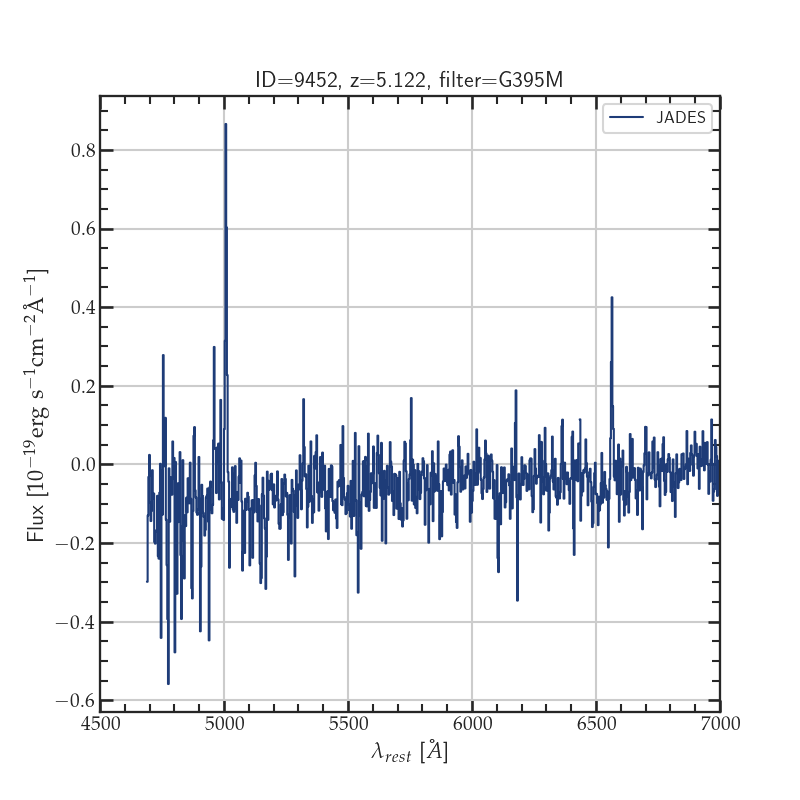

/home/nicolas/Documents/Research/PhD/JWST-Data/High_Resolution/Spectra1D/JADES/hlsp_jades_jwst_nirspec_goods-s-deephst-00009452_f290lp-g395h_v1.0_x1d.fits


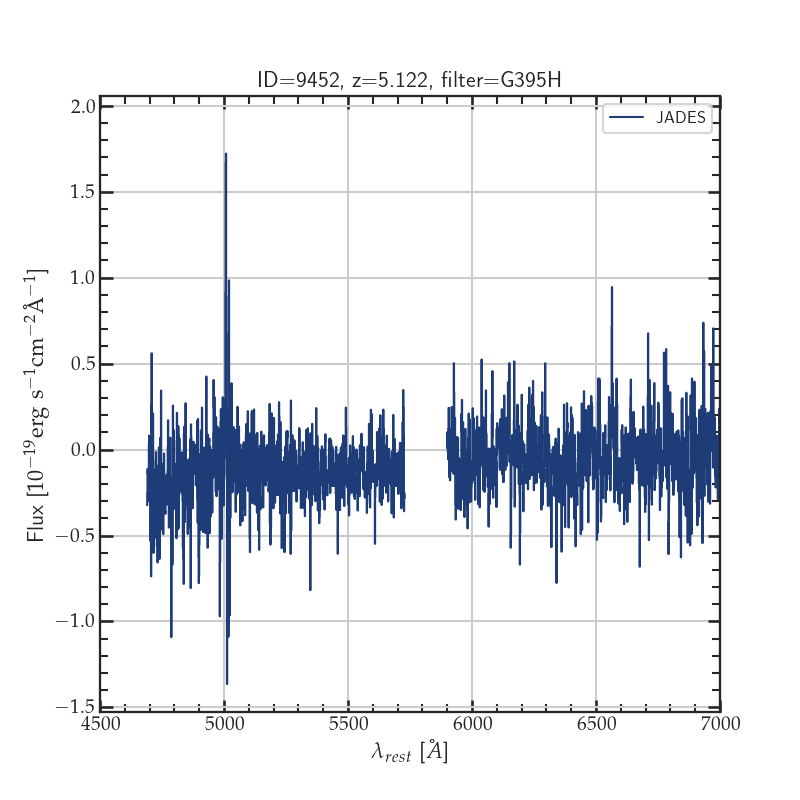

In [5]:
def main():

    
    ID = 9452
    
    for i in ID_array:
        
        index = np.where(ID_array == ID)[0][0]

    for filter in ['G395M', 'G395H']:

        plot_spectrum_comparison(index, filter=filter, frame='rest', which='JADES', show=True)



def plot_spectrum(source, index, filter='PRISM', frame='rest', lstyle='-'):

    
    if filter == 'PRISM':
        folder = prism_folder
    elif filter == 'G235M' or filter == 'G395M' or filter=='G140M':
        folder = medium_folder
    elif filter == 'G235H' or filter == 'G395H':
        folder = high_folder
    else:
        raise ValueError("Unknown Filter ")
    

    files_list = df[f"{source}_FILENAME_{filter}"]

    
        
    file = folder / source / files_list[index]  
    ID = ID_array[index]
    z = z_array[index]#*5.198

    print(file)

    with fits.open(file) as f:
        #Extract data from the file
        specdata=f[1].data

        lambda_obs = specdata['WAVELENGTH'] * 1e-6 / 1e-10 #convert from um to AA.
        flux = specdata['FLUX'] * 1e19
        if source == 'MAST':
            flux = flux * 2.99792458E-05 /lambda_obs**2

        if frame == 'rest': 
            
            lambda_rest = lambda_obs / (1.+float(z))
            wl = lambda_rest
        else:
            wl = lambda_obs
        
    
    plt.title(f'ID={ID}, z={z:.3f}, filter={filter}')
    plt.ylabel(r' Flux [$10^{-19}  \mathrm{erg~s^{-1} cm^{-2} \AA^{-1} }$]')
    plt.xlabel(r' $\lambda_{rest}$ [$\AA$]')
    plt.minorticks_on()
    plt.xlim(4500, 7000)
    #plt.ylim(-0.08, 0.45)
    plt.tick_params(axis='x')
    plt.tick_params(axis='y')
    plt.step(wl, flux, label=source, linestyle=lstyle, where='mid', linewidth=1.5)
    plt.legend(loc='best')  
    

main()


/home/nicolas/Documents/Research/PhD/JWST-Data/Medium_Resolution/Spectra1D/JADES/hlsp_jades_jwst_nirspec_goods-s-deephst-10013704_f290lp-g395m_v1.0_x1d.fits


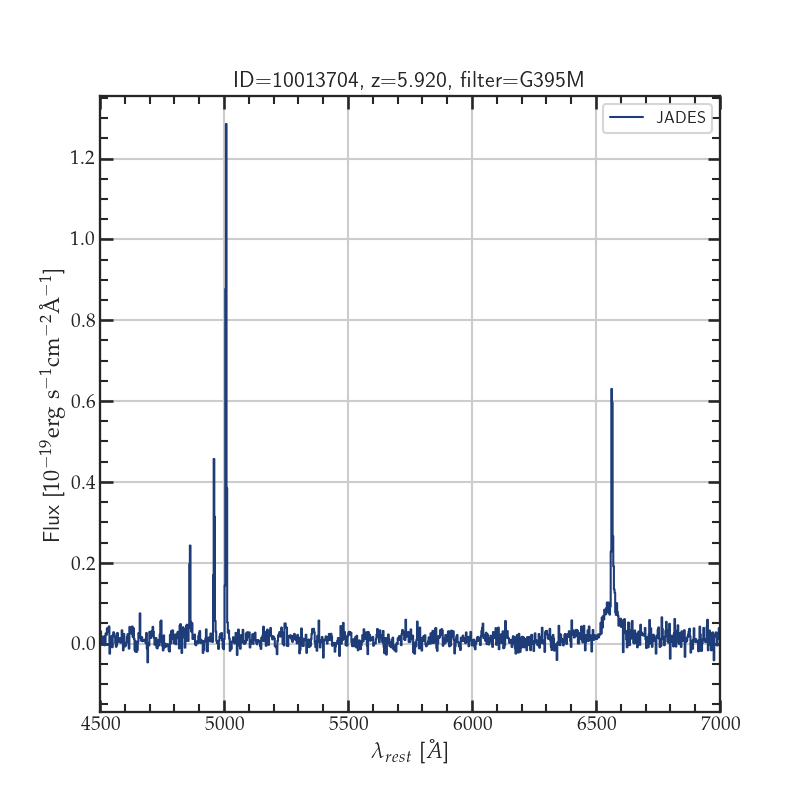

/home/nicolas/Documents/Research/PhD/JWST-Data/High_Resolution/Spectra1D/JADES/hlsp_jades_jwst_nirspec_goods-s-deephst-10013704_f290lp-g395h_v1.0_x1d.fits


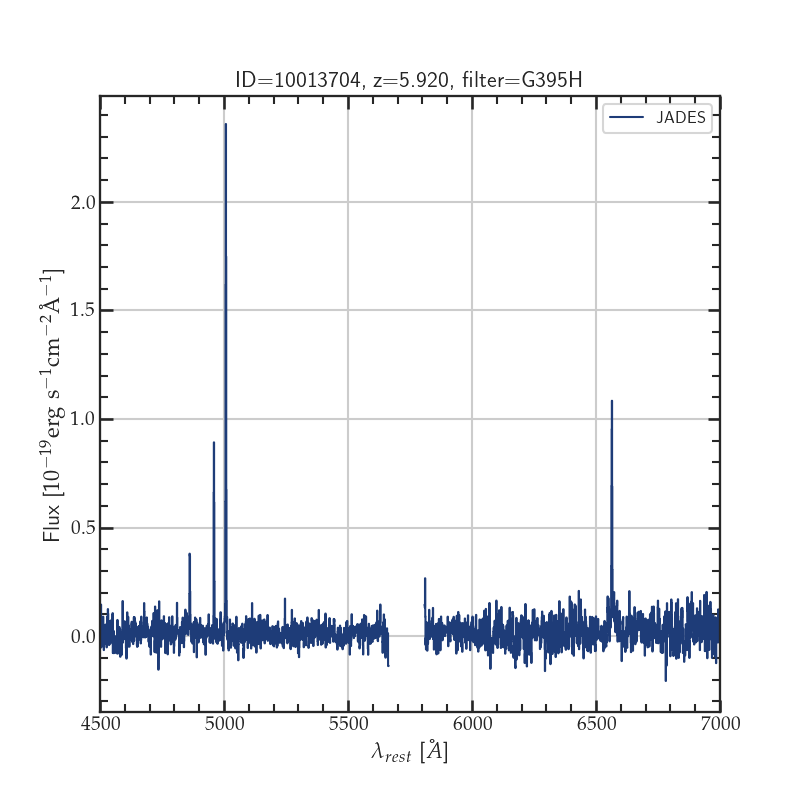

In [6]:
def main():

    
    ID = 10013704
    
    for i in ID_array:
        
        index = np.where(ID_array == ID)[0][0]

    for filter in ['G395M', 'G395H']:

        plot_spectrum_comparison(index, filter=filter, frame='rest', which='JADES', show=True)

main()

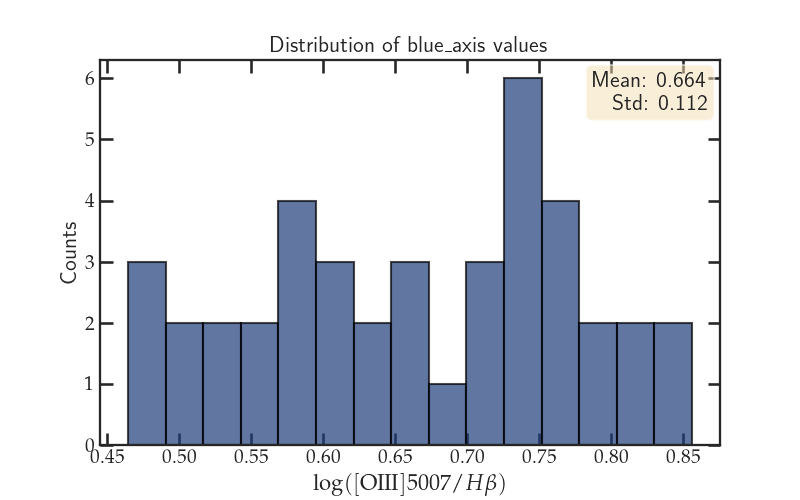

In [10]:
plt.figure(figsize=(8, 5))
blue_axis_filtered = df_jades_filtered['blue_axis'].dropna()
blue_axis_filtered = blue_axis_filtered[blue_axis_filtered >= 0.4]

plt.hist(blue_axis_filtered, bins=15, edgecolor='black', color=COSMO_COLORS['deep_blue'], alpha=0.7)
plt.xlabel(r'$\log([\mathrm{OIII}]5007/H\beta)$')
plt.ylabel('Counts')
plt.title('Distribution of blue_axis values')
plt.grid(False)

mean_val = blue_axis_filtered.mean()
std_val = blue_axis_filtered.std()
plt.text(0.98, 0.97, f'Mean: {mean_val:.3f}\nStd: {std_val:.3f}', 
         transform=plt.gca().transAxes, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.show()